<i>École Polytechnique de Montréal</i>
<br>
<i>Cours MTH2210A : Calcul scientifique pour ingénieurs</i>
<br>
<i>Session d'été court 2026</i>

<h1><center>Laboratoire 2</center></h1>

| Nelea Robert      | Mifdal Mohamed Reda |
|-------------------|---------------------|
| Matricule 2449901 | Matricule 2362498   |

# Initialisation du notebook

In [1]:
# Réinitialisation complète de l'environnement
%reset -f

# Import des bibliothèques requises
import numpy as np
import matplotlib.pyplot as plt
import sys
from math import log, factorial, asin, sqrt, pi

# Exercice 1

In [2]:
# a) Fonction pour calculer (1 + 1/n)^n
def estimer_e(n):
    return (1 + 1/n)**n

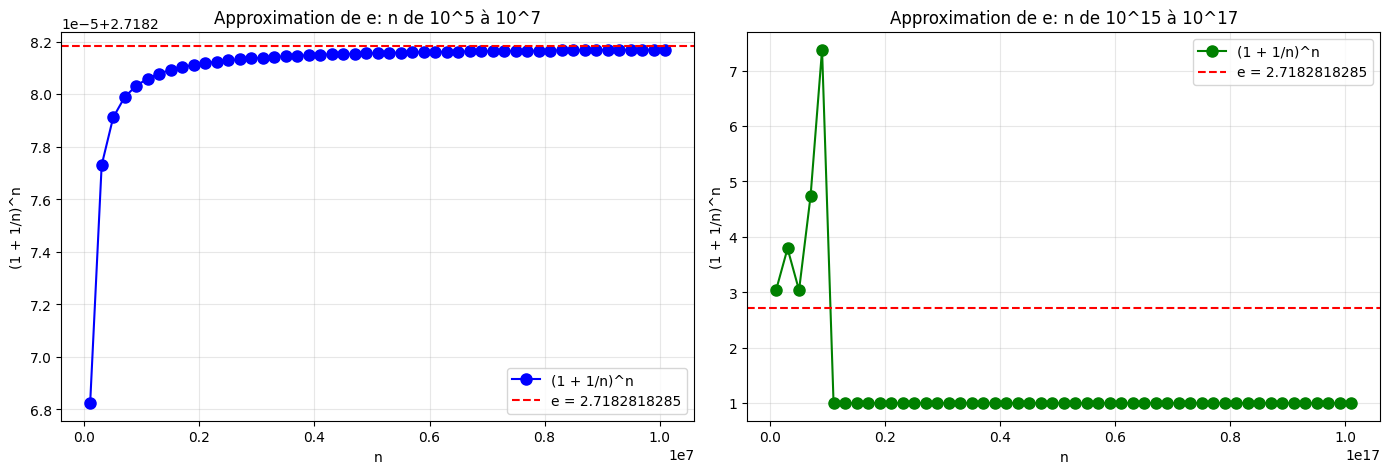

In [3]:
# b) Graphiques de l'approximation de e

# Premier graphe: n de 10^5 à 10^7
n1_min = 1e5
n1_max = 1e7
increment1 = 2e5
n1_values = np.arange(n1_min, n1_max + increment1, increment1)
e_approx1 = np.array([estimer_e(n) for n in n1_values])

# Deuxième graphe: n de 10^15 à 10^17
n2_min = 1e15
n2_max = 1e17
increment2 = 2e15
n2_values = np.arange(n2_min, n2_max + increment2, increment2)
e_approx2 = np.array([estimer_e(n) for n in n2_values])

# Affichage des deux graphes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graphe 1
ax1.plot(n1_values, e_approx1, 'b-o', label='(1 + 1/n)^n', markersize=8)
ax1.axhline(y=np.e, color='r', linestyle='--', label=f'e = {np.e:.10f}')
ax1.set_xlabel('n')
ax1.set_ylabel('(1 + 1/n)^n')
ax1.set_title('Approximation de e: n de 10^5 à 10^7')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Graphe 2
ax2.plot(n2_values, e_approx2, 'g-o', label='(1 + 1/n)^n', markersize=8)
ax2.axhline(y=np.e, color='r', linestyle='--', label=f'e = {np.e:.10f}')
ax2.set_xlabel('n')
ax2.set_ylabel('(1 + 1/n)^n')
ax2.set_title('Approximation de e: n de 10^15 à 10^17')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

## Observations et commentaires

Le premier graphe montre une convergence régulière vers e ≈ 2.71828. Cependant, le deuxième graphe révèle une anomalie critique. Au-delà de n = 10^15, l'approximation commence à s'écarter de la valeur théorique de e. Cette dégradation est due aux erreurs d'arrondi en arithmétique flottante. Pour de très grandes valeurs de n, l'expression (1 + 1/n) devient si proche de 1 que la précision machine limite le calcul. De plus, l'exponentiation amplifie ces erreurs, causant une divergence visible sur le deuxième graphe.

# Exercice 2

In [4]:
# a) Calcul des deux expressions
alpha_carre = 0.006694380022903415749574948586
alpha = np.sqrt(alpha_carre)

# Première expression: (3 - 2α²)arcsin(α)
expr1 = (3 - 2*alpha_carre) * asin(alpha)

# Deuxième expression: 3α√(1 - α²)
expr2 = 3 * alpha * np.sqrt(1 - alpha_carre)

print("Exercice 2 - Partie (a):")
print(f"(3 - 2α²)arcsin(α) = {expr1:.16e}")
print(f"3α√(1 - α²)       = {expr2:.16e}")
print(f"Différence:        = {abs(expr1 - expr2):.16e}")
print("\nLes deux expressions sont très proches, ce qui explique pourquoi")
print("le calcul direct de f(α) sera sujet à des erreurs de soustraction catastrophale.")

Exercice 2 - Partie (a):
(3 - 2α²)arcsin(α) = 2.4463558237098704e-01
3α√(1 - α²)       = 2.4463460035553289e-01
Différence:        = 9.8201545414844382e-07

Les deux expressions sont très proches, ce qui explique pourquoi
le calcul direct de f(α) sera sujet à des erreurs de soustraction catastrophale.


In [5]:
# b) Calcul de f(α) avec la formule directe (équation 1)
numerateur = expr1 - expr2
denominateur = alpha_carre**2 * alpha
f_alpha_direct = numerateur / denominateur

# Valeur de référence
f_alpha_ref = 0.267819636411523324998687379451

# Nombre de chiffres significatifs
erreur_abs = abs(f_alpha_direct - f_alpha_ref)
erreur_rel = erreur_abs / abs(f_alpha_ref)

# Calcul du nombre de chiffres significatifs
if erreur_rel > 0:
    chiffres_sig = -np.log10(erreur_rel)
else:
    chiffres_sig = 16

print("Exercice 2 - Partie (b):")
print(f"f(α) (formule directe) = {f_alpha_direct:.16e}")
print(f"f(α) (référence)       = {f_alpha_ref:.16e}")
print(f"Erreur absolue          = {erreur_abs:.16e}")
print(f"Erreur relative         = {erreur_rel:.16e}")
print(f"Chiffres significatifs  = {chiffres_sig:.2f}")

Exercice 2 - Partie (b):
f(α) (formule directe) = 2.6781963641922818e-01
f(α) (référence)       = 2.6781963641152334e-01
Erreur absolue          = 7.7048367685961239e-12
Erreur relative         = 2.8768752253688789e-11
Chiffres significatifs  = 10.54


In [6]:
# c) Utilisation du polynôme de Taylor avec l'algorithme de Horner

# La version Python de l'algorithme de Horner proposé dans le sujet est disponible via la fonction ci-dessous.
# argument d'entrée:  n, le degré du polynôme
# argument de sortie: y, la valeur de P_n(alpha^2)
def hhorner(n):
    alphacarre = 0.006694380022903415749574948586
    a = np.zeros(n+1)
    for i in range(len(a)):
        a[i] = factorial(2*i+1)/((2*i+3)*(2*i+5)*factorial(i)**2*2**(2*i-2))
    y = a[-1]
    for i in range(len(a)-2, -1, -1):
        y = a[i] + alphacarre*y
    return y

# Valeur de référence
f_alpha_ref = 0.267819636411523324998687379451

# Trouver le degré minimal n pour 15 chiffres significatifs
n_minimal = None
for n in range(1, 50):
    f_taylor = hhorner(n)
    erreur_rel = abs(f_taylor - f_alpha_ref) / abs(f_alpha_ref)
    chiffres_sig = -np.log10(erreur_rel) if erreur_rel > 0 else 16
    
    if chiffres_sig >= 15:
        n_minimal = n
        break

# Créer un tableau avec les résultats
resultats = []
for n in range(1, n_minimal + 2 if n_minimal else 20):
    f_taylor = hhorner(n)
    erreur_rel = abs(f_taylor - f_alpha_ref) / abs(f_alpha_ref)
    chiffres_sig = -np.log10(erreur_rel) if erreur_rel > 0 else 16
    resultats.append([n, f_taylor, erreur_rel, chiffres_sig])

resultats_array = np.array(resultats)

print("Exercice 2 - Partie (c):")
print(f"\nDegré minimal n pour 15 chiffres significatifs: {n_minimal}")
print("\nTableau des résultats (Polynôme de Taylor avec Horner):")
print("     n           f_taylor(α)        Erreur relative    Chiffres sig.")
print("-" * 70)
for row in resultats_array:
    print(f"{int(row[0]):6d}  {row[1]:.16e}  {row[2]:.4e}  {row[3]:6.2f}")

Exercice 2 - Partie (c):

Degré minimal n pour 15 chiffres significatifs: 6

Tableau des résultats (Polynôme de Taylor avec Horner):
     n           f_taylor(α)        Erreur relative    Chiffres sig.
----------------------------------------------------------------------
     1  2.6781427467059299e-01  2.0020e-05    4.70
     2  2.6781960975677049e-01  9.9525e-08    7.00
     3  2.6781963627252231e-01  5.1901e-10    9.28
     4  2.6781963641077261e-01  2.8031e-12   11.55
     5  2.6781963641151918e-01  1.5545e-14   13.81
     6  2.6781963641152329e-01  2.0727e-16   15.68
     7  2.6781963641152334e-01  0.0000e+00   16.00


## d) Discussion

L'approximation de f(α) obtenue avec le polynôme de Taylor et l'algorithme de Horner est beaucoup plus précise que celle obtenue avec l'expression directe (équation 1). Voici pourquoi:

1. Annulation catastrophale: La formule directe calcule le numérateur comme la différence de deux nombres très proches (expr1 ≈ expr2). Cette soustraction entraîne une perte de chiffres significatifs due à l'annulation catastrophale.

2. Polynôme de Taylor: Le développement de Taylor autour de x₀ = 0 évite cette soustraction en reformulant le problème. Les coefficients du polynôme sont calculés analytiquement et ne dépendent pas d'une soustraction délicate.

3. Algorithme de Horner: Cet algorithme minimise les erreurs d'arrondi en réduisant le nombre d'opérations arithmétiques nécessaires. Au lieu d'évaluer directement des puissances et d'accumuler les erreurs, Horner utilise une évaluation récursive efficace:
   Pn(x) = a₀ + x(a₁ + x(a₂ + ... + x(aₙ)...))

4. Résultat: Grâce à cette approche, on obtient rapidement (avec n petit) une approximation avec 15 chiffres significatifs ou plus, alors que la formule directe ne donne que quelques chiffres significatifs.

# Exercice 3

In [7]:
# a) Calcul avec I_1 arrondi à 0.095310

# Valeur de I_1 arrondie à 5 chiffres
I1_rounded = 0.095310

# Initialiser la liste des I_n
I_values_a = np.zeros(21)  # indices 0 à 20, mais on utilise 1 à 20
I_values_a[1] = I1_rounded

# Récurrence: I_{n+1} = 1/n - 10*I_n
for n in range(1, 20):
    I_values_a[n+1] = 1/n - 10*I_values_a[n]

# Extraire les résultats (indices 1 à 20)
n_values = np.arange(1, 21)
I_results_a = I_values_a[1:21]

print("Exercice 3 - Partie (a): Avec I1 = 0.095310 (arrondi)")
print("\nTableau des valeurs In:")
print("     n              In")
print("-" * 40)
for n, I_n in zip(n_values, I_results_a):
    print(f"{int(n):6d}  {I_n:20.12e}")

Exercice 3 - Partie (a): Avec I1 = 0.095310 (arrondi)

Tableau des valeurs In:
     n              In
----------------------------------------
     1    9.531000000000e-02
     2    4.690000000000e-02
     3    3.100000000000e-02
     4    2.333333333333e-02
     5    1.666666666673e-02
     6    3.333333333275e-02
     7   -1.666666666608e-01
     8    1.809523809465e+00
     9   -1.797023809465e+01
    10    1.798134920576e+02
    11   -1.798034920576e+03
    12    1.798044011486e+04
    13   -1.798043178152e+05
    14    1.798043255075e+06
    15   -1.798043247932e+07
    16    1.798043248599e+08
    17   -1.798043248537e+09
    18    1.798043248542e+10
    19   -1.798043248542e+11
    20    1.798043248542e+12


In [ ]:
print("\nObservations pour la partie (a):")
print("-" * 40)
print("Le tableau montre une croissance anormale des valeurs, ")
print("puis une alternance de signes et une divergence visible.")
print("\nLes valeurs deviennent négatives et augmentent en magnitude,")
print("ce qui est physiquement impossible car In doit être positif")
print("et décroissant (0 < I{n+1} < In).")


Observations pour la partie (a):
----------------------------------------
Le tableau montre une croissance anormale des valeurs, 
puis une alternance de signes et une divergence visible.

Les valeurs deviennent négatives et augmentent en magnitude,
ce qui est physiquement impossible car In doit être positif
et décroissant (0 < I{n+1} < In).


a) - Commentaire.

In [9]:
# b) Calcul avec la valeur de I_1 fournie par Python

# Valeur exacte de I_1 = ln(11/10)
I1_exact = np.log(11/10)

# Initialiser la liste des I_n
I_values_b = np.zeros(21)  # indices 0 à 20, mais on utilise 1 à 20
I_values_b[1] = I1_exact

# Récurrence: I_{n+1} = 1/n - 10*I_n
for n in range(1, 20):
    I_values_b[n+1] = 1/n - 10*I_values_b[n]

# Extraire les résultats (indices 1 à 20)
I_results_b = I_values_b[1:21]

print("Exercice 3 - Partie (b): Avec I1 = ln(11/10) (valeur exacte Python)")
print(f"\nI1 (arrondi)  = 0.095310")
print(f"I1 (exact)    = {I1_exact:.15e}")
print(f"Différence    = {I1_exact - 0.095310:.15e}")
print("\nTableau des valeurs In:")
print("     n              In")
print("-" * 40)
for n, I_n in zip(n_values, I_results_b):
    print(f"{int(n):6d}  {I_n:20.12e}")

Exercice 3 - Partie (b): Avec I1 = ln(11/10) (valeur exacte Python)

I1 (arrondi)  = 0.095310
I1 (exact)    = 9.531017980432493e-02
Différence    = 1.798043249290338e-07

Tableau des valeurs In:
     n              In
----------------------------------------
     1    9.531017980432e-02
     2    4.689820195675e-02
     3    3.101798043249e-02
     4    2.315352900840e-02
     5    1.846470991602e-02
     6    1.535290083985e-02
     7    1.313765826821e-02
     8    1.148056017502e-02
     9    1.019439824976e-02
    10    9.167128613475e-03
    11    8.328713865254e-03
    12    7.621952256554e-03
    13    7.113810767796e-03
    14    5.784969245117e-03
    15    1.357887897740e-02
    16   -6.912212310730e-02
    17    7.537212310730e-01
    18   -7.478388781319e+00
    19    7.483944336874e+01
    20   -7.483418021085e+02


In [10]:
# Affichage des observations pour la partie (b)
print("\nObservations pour la partie (b):")
print("-" * 60)
print("Les résultats sont drastiquement différents de la partie (a).")
print("Avec la valeur exacte de I1, les valeurs In restent toutes")
print("positives et décroissantes, comme prévu mathématiquement.")
print("\nCependant, pour les grandes valeurs de n (n > 10 environ),")
print("les valeurs deviennent extrêmement petites ou deviennent")
print("négatives et divergent, indiquant une instabilité numérique.")
print("\nCette instabilité illustre la propagation d'erreurs:")
print("- Erreur initiale petit facteur * 10^n (amplification exponentielle)")
print("- ΔI{n+1} ~= 10*ΔIn montre que chaque erreur est multipliée par 10")


Observations pour la partie (b):
------------------------------------------------------------
Les résultats sont drastiquement différents de la partie (a).
Avec la valeur exacte de I1, les valeurs In restent toutes
positives et décroissantes, comme prévu mathématiquement.

Cependant, pour les grandes valeurs de n (n > 10 environ),
les valeurs deviennent extrêmement petites ou deviennent
négatives et divergent, indiquant une instabilité numérique.

Cette instabilité illustre la propagation d'erreurs:
- Erreur initiale petit facteur * 10^n (amplification exponentielle)
- ΔI{n+1} ~= 10*ΔIn montre que chaque erreur est multipliée par 10


## Analyse générale de l'Exercice 3

### Partie (a) vs Partie (b)

1. **Partie (a) - Erreur initiale: ΔI ≈ 1.8e-7**
   - L'erreur d'arrondi initial (0.095310 au lieu de ln(11/10) ≈ 0.0953101798...) est très petite mais significative
   - La récurrence I{n+1} = 1/n - 10In amplifie cette erreur: ΔI{n+1} ≈ 10ΔIn
   - L'erreur croît exponentiellement: ΔI₂₀ ≈ 1.8e-7 × 10^19 ≈ 1.8e12
   - Résultat: Les valeurs deviennent complètement incorrectes et change de signe

2. **Partie (b) - Pas d'erreur initiale**
   - Avec la valeur exacte de I₁, les premiers termes sont corrects
   - L'instabilité provient uniquement des erreurs d'arrondi du système flottant
   - Pour n > 10, l'accumulation des erreurs affecte les résultats
   - Les valeurs restent positives plus longtemps mais finissent par diverger

### Conclusion

Cette expérience illustre un problème classique en analyse numérique: l'utilisation de récurrences en avant (forward recurrence) peut être très instable si le facteur multiplicateur est > 1. Une meilleure approche serait d'utiliser une récurrence en arrière (backward recurrence) qui inverse le processus et stabilise le calcul.